# What did we find in 100,000 policies?

We sampled 100k policy snippets (stratified across our 11 sectors) from a corpus of ~1.5 million. Then we asked an AI classifier — DeepSeek V4, calibrated with 10 expert-labelled examples — to sort each one into one of five categories:

- **Sufficiency** — the policy reduces the absolute level of demand (with a sub-mechanism: caps/bans, passive design, modal shift, public provisioning, etc.).
- **Efficiency** — same service, less input per unit.
- **Consistency** — same service, cleaner input.
- **Ambiguous** — clearly a policy, mechanism unclear.
- **Not a policy** — descriptive statement, data, or implementation detail — not an actual policy instrument.

Then, separately, we asked the AI to judge how coherent our existing topical clusters are (via a 5-way "odd one out" test) on a random 500-cluster sample.

This notebook explores both outputs and shows what decisions we can make from them.

**Sources:**
- `runs/api_100k/classifications.jsonl` — 99,999 successful classifications, 1 schema failure.
- `runs/api_100k/judgments.jsonl` — 433 cluster verdicts.
- `runs/api_100k/per_cluster_stats.parquet` — per-cluster sufficiency density.
- `runs/api_100k/per_cluster.csv` — joined table used for the 2×2 report.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

OUT = Path("../../runs/api_100k")

def _jsonl(p):
    return pd.DataFrame([json.loads(l) for l in Path(p).read_text().splitlines() if l.strip()])

items = _jsonl(OUT / "to_classify.jsonl")
preds = _jsonl(OUT / "classifications.jsonl")
if "error" in preds.columns:
    preds = preds[preds["error"].isna()].copy()

# Pair each item with its classification (see aggregate_100k.py for why).
items["_seq"] = items.groupby(["policy_uid", "cluster_uid"]).cumcount()
preds["_seq"] = preds.groupby(["policy_uid", "cluster_uid"]).cumcount()
df = items.merge(
    preds[["policy_uid", "cluster_uid", "_seq", "category", "sub_code", "confidence"]],
    on=["policy_uid", "cluster_uid", "_seq"],
    how="inner",
)

judgments = _jsonl(OUT / "judgments.jsonl")
if "error" in judgments.columns:
    judgments = judgments[judgments["error"].isna()].copy()
judgments["correct"] = (judgments["intruder_index"] == judgments["gold_intruder_index"]).astype(int)

cluster_stats = pd.read_parquet(OUT / "per_cluster_stats.parquet")
per_cluster = pd.read_csv(OUT / "per_cluster.csv")

print(f"classifications: {len(df):,}")
print(f"cluster verdicts: {len(judgments):,}")
print(f"clusters with density data: {len(cluster_stats):,}")
print(f"joined per-cluster rows: {len(per_cluster):,}")

classifications: 99,999
cluster verdicts: 433
clusters with density data: 988
joined per-cluster rows: 415


## 1. The big picture — what are these 100,000 texts, according to the AI?

Almost half the sample turns out to be **not actual policy text** — study observations, method descriptions, implementation notes. That's not a model failure; it's what the source corpus looks like. It's why we need the filter step: everything downstream of the classifier only sees the ~34% that IS about a real policy AND is sufficiency-related.

**Sufficiency** is our target category, and it accounts for about **30%** of the sample. Combined with `Ambiguous` (borderline cases we want to keep for review), the surviving pool is ~33,500 sufficiency-related policies out of 100k.

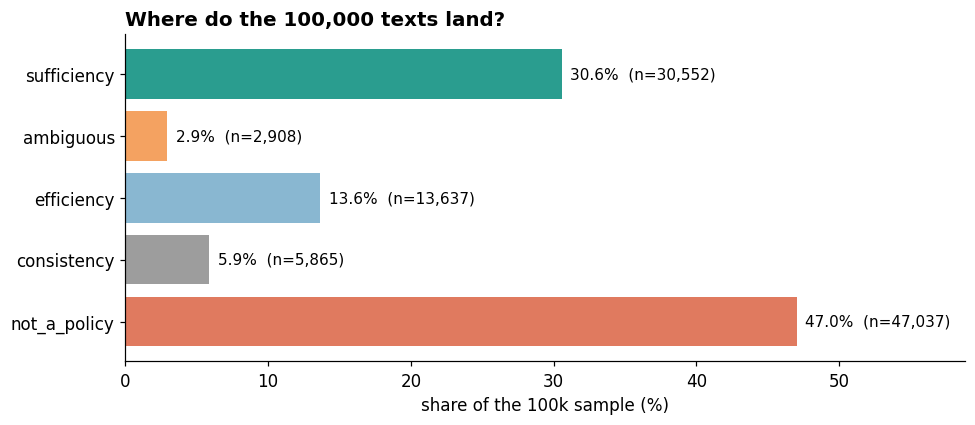

In [2]:
order = ["sufficiency", "ambiguous", "efficiency", "consistency", "not_a_policy"]
colors = {
    "sufficiency": "#2a9d8f",       # teal — the thing we care about
    "ambiguous": "#f4a261",          # amber — hedging
    "efficiency": "#89b7d1",         # muted blue — adjacent, not what we want
    "consistency": "#9d9d9d",        # grey — off-topic
    "not_a_policy": "#e07a5f",       # rusty red — junk filter
}

dist = df["category"].value_counts().reindex(order)
share = dist / dist.sum()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(order[::-1], share.loc[order[::-1]] * 100, color=[colors[c] for c in order[::-1]])
for b, cat in zip(bars, order[::-1]):
    ax.text(b.get_width() + 0.6, b.get_y() + b.get_height() / 2,
            f"{share[cat]*100:.1f}%  (n={int(dist[cat]):,})",
            va="center", fontsize=10)
ax.set_xlim(0, share.max() * 100 * 1.25)
ax.set_xlabel("share of the 100k sample (%)")
ax.set_title("Where do the 100,000 texts land?", fontsize=13, fontweight="bold", loc="left")
plt.tight_layout()
plt.show()

## 2. Which sectors are sufficiency-rich?

Sectors differ a lot in how much of their content is actually about sufficiency. **URBAN and SOCIAL** stand out — nearly half of what shows up under those tags qualifies as sufficiency. **ENERGY and INDUSTRY** sit at the other end: sufficiency accounts for ~13% each, and "Not a policy" dominates the rest (a lot of technical description gets tagged to these sectors).

The teal bar (sufficiency) plus the amber slice (ambiguous) is what would flow into the downstream sufficiency index.

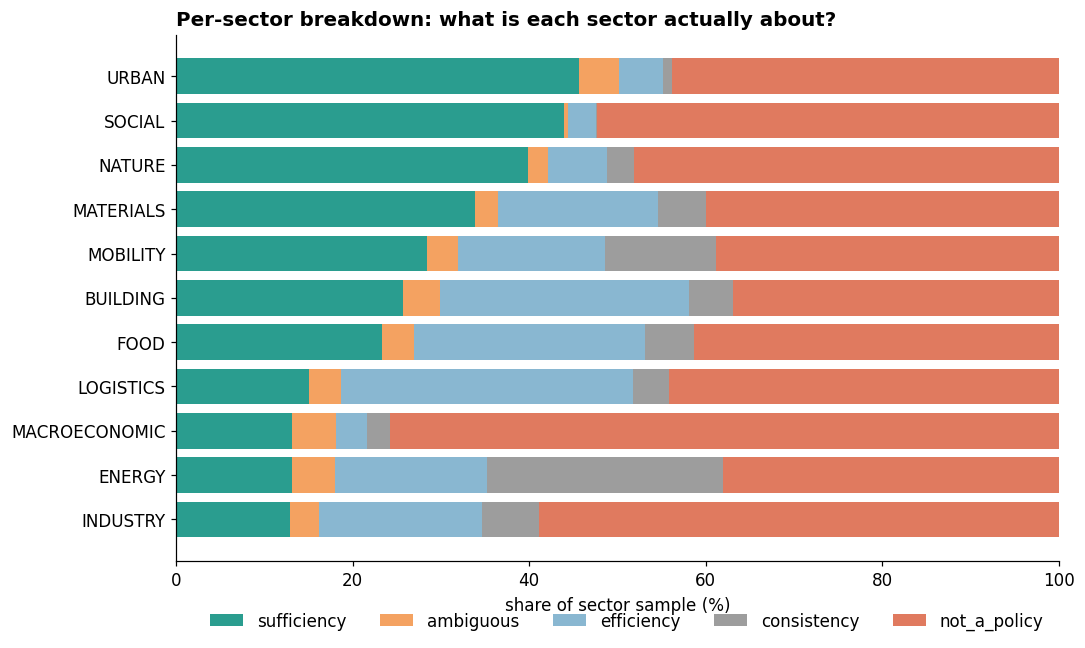

In [3]:
sec = (
    df.groupby(["sector", "category"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=order, fill_value=0)
)
sec_shares = sec.div(sec.sum(axis=1), axis=0) * 100
sec_shares = sec_shares.sort_values("sufficiency", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
left = np.zeros(len(sec_shares))
for cat in order:
    ax.barh(sec_shares.index, sec_shares[cat], left=left, color=colors[cat], label=cat)
    left = left + sec_shares[cat].values
ax.set_xlim(0, 100)
ax.set_xlabel("share of sector sample (%)")
ax.set_title("Per-sector breakdown: what is each sector actually about?", fontsize=13, fontweight="bold", loc="left")
ax.legend(loc="lower right", ncols=5, bbox_to_anchor=(1.0, -0.16), frameon=False)
plt.tight_layout()
plt.show()

## 3. When it IS sufficiency, what kind of sufficiency?

For every policy tagged `sufficiency`, the model also picks one of ten sub-mechanisms (from the expert taxonomy). Two codes dominate:

- **Caps, limits & bans** (code 1) — quotas, protected areas, hard regulatory ceilings.
- **Public provisioning** (code 9) — collective/universal provision that secures needs at low throughput.

The third and fourth largest are **Proximity & compactness** (spatial-avoidance, mostly URBAN) and **Reduce & right size** (deliberate downscaling). The four "design-out-the-need" mechanisms — passive design, modal shift, share/reuse, dietary shift — each show up on the order of 1,000–1,500 policies.

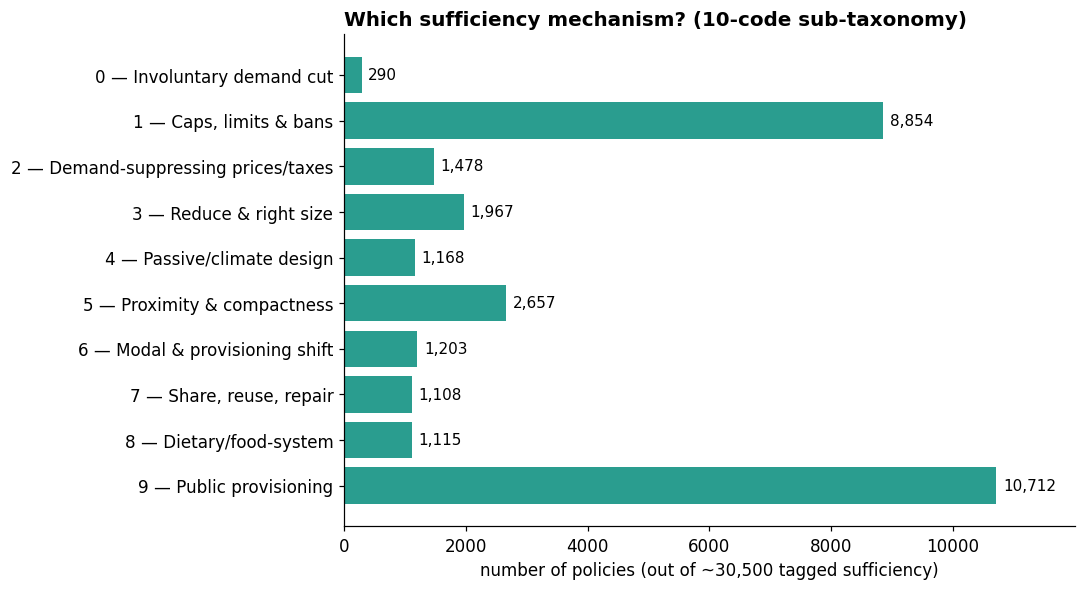

In [4]:
SUB_LABELS = {
    0: "0 — Involuntary demand cut",
    1: "1 — Caps, limits & bans",
    2: "2 — Demand-suppressing prices/taxes",
    3: "3 — Reduce & right size",
    4: "4 — Passive/climate design",
    5: "5 — Proximity & compactness",
    6: "6 — Modal & provisioning shift",
    7: "7 — Share, reuse, repair",
    8: "8 — Dietary/food-system",
    9: "9 — Public provisioning",
}

suff = df[df["category"] == "sufficiency"].dropna(subset=["sub_code"]).copy()
suff["sub_code"] = suff["sub_code"].astype(int)
sub_dist = suff["sub_code"].value_counts().sort_index()

labels = [SUB_LABELS[c] for c in sub_dist.index]
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(labels, sub_dist.values, color="#2a9d8f")
for b, v in zip(bars, sub_dist.values):
    ax.text(v + max(sub_dist.values) * 0.01, b.get_y() + b.get_height() / 2,
            f"{v:,}", va="center", fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, max(sub_dist.values) * 1.12)
ax.set_xlabel("number of policies (out of ~30,500 tagged sufficiency)")
ax.set_title("Which sufficiency mechanism? (10-code sub-taxonomy)", fontsize=13, fontweight="bold", loc="left")
plt.tight_layout()
plt.show()

## 4. How confident was the classifier?

Every classification comes with a self-reported confidence 1–5. On sufficiency and not_a_policy the model is highly certain (mostly 5). It hedges most on `ambiguous`, as designed — that's the pressure valve. Consistency and efficiency sit in between.

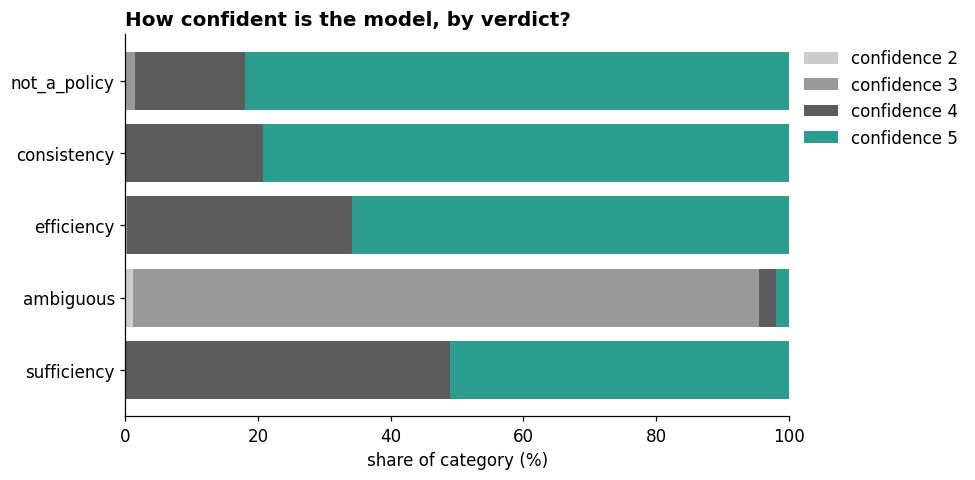

In [5]:
conf = df.groupby(["category", "confidence"]).size().unstack(fill_value=0)
conf = conf.reindex(order).fillna(0)
shares = conf.div(conf.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
left = np.zeros(len(shares))
conf_colors = ["#eeeeee", "#cccccc", "#999999", "#5c5c5c", "#2a9d8f"]
for i, c in enumerate([1, 2, 3, 4, 5]):
    if c in shares.columns:
        ax.barh(shares.index, shares[c], left=left, color=conf_colors[i], label=f"confidence {c}")
        left = left + shares[c].values
ax.set_xlim(0, 100)
ax.set_xlabel("share of category (%)")
ax.set_title("How confident is the model, by verdict?", fontsize=13, fontweight="bold", loc="left")
ax.legend(bbox_to_anchor=(1.0, 1.0), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

## 5. Are the existing clusters coherent? (the "odd one out" test)

We showed the judge 5 statements — 4 from one cluster + 1 from a different cluster in the same sector — for **433 randomly-chosen clusters**. Random guessing scores **20%**. The judge got **73.5%** right overall.

Cluster size matters: big clusters have a strong topical signal and are easy to judge; tiny ones are noisier. **Small clusters (≤50 members)** drop to 59% accuracy — worth reviewing whether Leiden should merge those.

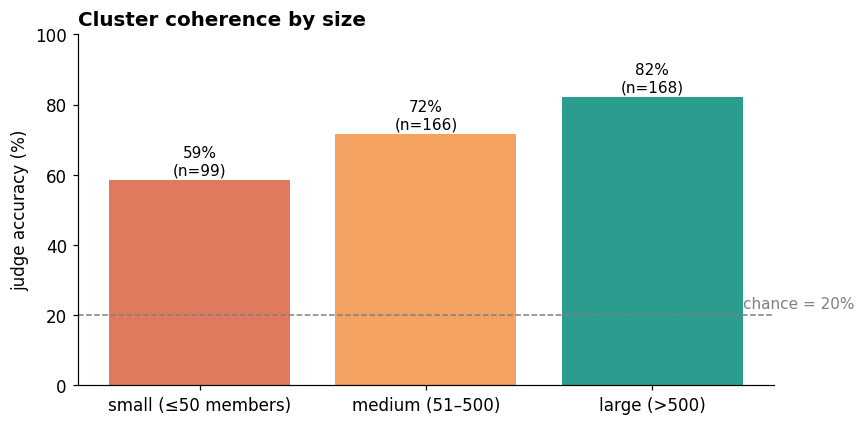

In [6]:
bucket_order = ["small", "medium", "large"]
bucket_labels = {"small": "small (≤50 members)", "medium": "medium (51–500)", "large": "large (>500)"}
acc_by_bucket = judgments.groupby("size_bucket")["correct"].agg(["mean", "count"]).reindex(bucket_order)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    [bucket_labels[b] for b in bucket_order],
    acc_by_bucket["mean"] * 100,
    color=["#e07a5f", "#f4a261", "#2a9d8f"],
)
ax.axhline(20, color="grey", linestyle="--", linewidth=1)
ax.text(2.4, 22, "chance = 20%", color="grey", fontsize=10)
for b, (bkt, row) in zip(bars, acc_by_bucket.iterrows()):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1.5,
            f"{row['mean']*100:.0f}%\n(n={int(row['count'])})",
            ha="center", fontsize=10)
ax.set_ylim(0, 100)
ax.set_ylabel("judge accuracy (%)")
ax.set_title("Cluster coherence by size", fontsize=13, fontweight="bold", loc="left")
plt.tight_layout()
plt.show()

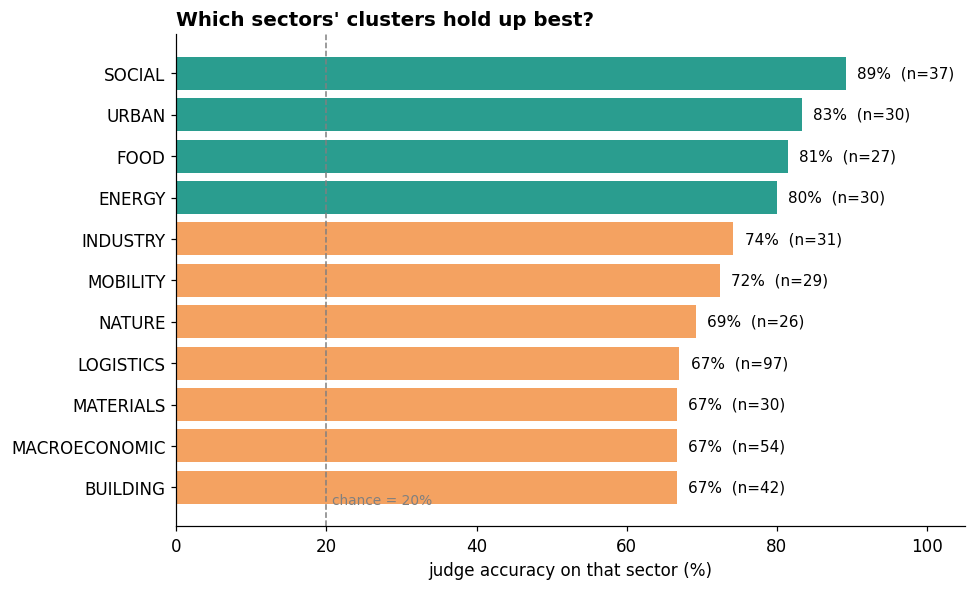

In [7]:
sec_acc = judgments.groupby("sector")["correct"].agg(["mean", "count"]).sort_values("mean")

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(sec_acc.index, sec_acc["mean"] * 100,
               color=["#e07a5f" if v < 0.6 else "#f4a261" if v < 0.75 else "#2a9d8f" for v in sec_acc["mean"]])
ax.axvline(20, color="grey", linestyle="--", linewidth=1)
ax.text(20.7, -0.4, "chance = 20%", color="grey", fontsize=9)
for b, (sec, row) in zip(bars, sec_acc.iterrows()):
    ax.text(b.get_width() + 1.5, b.get_y() + b.get_height() / 2,
            f"{row['mean']*100:.0f}%  (n={int(row['count'])})",
            va="center", fontsize=10)
ax.set_xlim(0, 105)
ax.set_xlabel("judge accuracy on that sector (%)")
ax.set_title("Which sectors' clusters hold up best?", fontsize=13, fontweight="bold", loc="left")
plt.tight_layout()
plt.show()

## 6. Putting classifier + judge together: the 2×2 decision matrix

Every judged cluster has two independent signals:

- **Judge verdict**: does the cluster hold together topically? (yes / no)
- **Sufficiency density**: is the majority (≥50%) of the cluster actually about sufficiency?

Crossing them gives four buckets:

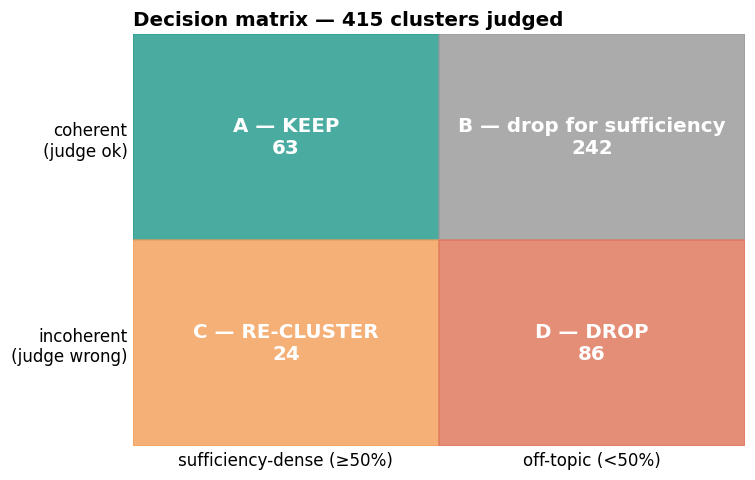

KEEP:              63  (15%)
drop-for-sufficiency: 242  (58%)
RE-CLUSTER:        24  (6%)
DROP:              86  (21%)


In [8]:
per_cluster["judge_ok"] = per_cluster["judge_correct"] == 1
per_cluster["suff_high"] = per_cluster["density_loose"].fillna(0) >= 0.5

counts = per_cluster.groupby(["judge_ok", "suff_high"]).size()
def cell(jo, sh):
    try: return int(counts.loc[(jo, sh)])
    except KeyError: return 0
A = cell(True, True)       # coherent + sufficiency-dense: KEEP
B = cell(True, False)      # coherent but off-topic: drop for sufficiency
C = cell(False, True)      # incoherent but sufficiency-dense: RE-CLUSTER
D = cell(False, False)     # incoherent + off-topic: DROP

labels = np.array([[f"A — KEEP\n{A}", f"B — drop for sufficiency\n{B}"],
                   [f"C — RE-CLUSTER\n{C}", f"D — DROP\n{D}"]])
values = np.array([[A, B], [C, D]])

fig, ax = plt.subplots(figsize=(7, 4.5))
cmap_colors = np.array([["#2a9d8f", "#9d9d9d"],
                        ["#f4a261", "#e07a5f"]])
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1-i), 1, 1, color=cmap_colors[i, j], alpha=0.85))
        ax.text(j + 0.5, 1 - i + 0.5, labels[i, j], ha="center", va="center",
                fontsize=13, fontweight="bold", color="white")
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["sufficiency-dense (≥50%)", "off-topic (<50%)"])
ax.set_yticks([1.5, 0.5])
ax.set_yticklabels(["coherent\n(judge ok)", "incoherent\n(judge wrong)"])
ax.set_title(f"Decision matrix — {A+B+C+D} clusters judged", fontsize=13, fontweight="bold", loc="left")
ax.tick_params(length=0)
for s in ["top", "right", "left", "bottom"]:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

print(f"KEEP:              {A}  ({A/(A+B+C+D):.0%})")
print(f"drop-for-sufficiency: {B}  ({B/(A+B+C+D):.0%})")
print(f"RE-CLUSTER:        {C}  ({C/(A+B+C+D):.0%})")
print(f"DROP:              {D}  ({D/(A+B+C+D):.0%})")

**Reading the matrix**

- **A (KEEP)** — clusters that pass both tests. Ship to the downstream sufficiency index.
- **B (drop for sufficiency use)** — coherent clusters, but not about sufficiency. Legitimate for adjacent-topic maps; not needed here.
- **C (RE-CLUSTER)** — sufficiency-rich material grouped poorly. Highest-value cell: run Leiden with finer resolution on this slice.
- **D (DROP)** — noisy AND off-topic. No signal to preserve.

## 7. The KEEP shortlist — highest-signal clusters ready to ship

In [9]:
keep = per_cluster[per_cluster["judge_ok"] & per_cluster["suff_high"]].copy()
keep = keep.sort_values(["judge_confidence", "density_loose"], ascending=[False, False])
keep["sub_code_int"] = keep["top_subcode"].astype("Int64")
keep["sub"] = keep["sub_code_int"].map(lambda c: SUB_LABELS.get(int(c), "") if pd.notna(c) else "")

cols = ["cluster_uid", "sector", "cluster_size", "judge_confidence",
        "density_loose", "density_strict", "sub", "topic_label"]
keep[cols].head(20).style.format({
    "density_loose": "{:.0%}",
    "density_strict": "{:.0%}",
})

,cluster_uid,sector,cluster_size,judge_confidence,density_loose,density_strict,sub,topic_label
3,NATURE__103,NATURE,9,5,100%,50%,3 — Reduce & right size,international collaboration on natural resource management
136,MATERIALS__75,MATERIALS,51,5,100%,100%,3 — Reduce & right size,waste management and prevention
184,MOBILITY__86,MOBILITY,8,5,100%,100%,6 — Modal & provisioning shift,financial incentives for sustainable transport
195,MOBILITY__76,MOBILITY,17,5,100%,100%,6 — Modal & provisioning shift,promoting public and non-motorized transport
203,LOGISTICS__66,LOGISTICS,5,5,100%,0%,,low-carbon logistics
226,NATURE__95,NATURE,8,5,100%,100%,"1 — Caps, limits & bans",habitat and wildlife management
21,MOBILITY__51,MOBILITY,386,5,95%,95%,6 — Modal & provisioning shift,public transport promotion
336,URBAN__34,URBAN,4322,5,82%,81%,4 — Passive/climate design,urban heat island mitigation through green spaces
189,URBAN__59,URBAN,1290,5,81%,71%,"1 — Caps, limits & bans",ecological zoning and land use planning
289,FOOD__61,FOOD,3679,5,80%,76%,9 — Public provisioning,food assistance programs


## 8. The RE-CLUSTER shortlist — sufficiency-rich but grouped badly

These are the highest-value candidates for a second Leiden pass at finer resolution — a lot of sufficiency signal is trapped inside topically-incoherent groups.

In [10]:
recluster = per_cluster[(~per_cluster["judge_ok"]) & per_cluster["suff_high"]].copy()
recluster = recluster.sort_values("density_loose", ascending=False)

recluster["pick_vs_gold"] = recluster["intruder_index"].astype(int).astype(str) + " vs " + recluster["gold_intruder_index"].astype(int).astype(str)
cols = ["cluster_uid", "sector", "cluster_size", "density_loose", "pick_vs_gold", "topic_label"]
recluster[cols].head(20).style.format({"density_loose": "{:.0%}"})

,cluster_uid,sector,cluster_size,density_loose,pick_vs_gold,topic_label
200,MOBILITY__69,MOBILITY,29,100%,1 vs 2,efficient transportation planning
255,MATERIALS__89,MATERIALS,6,100%,0 vs 4,waste management and environmental awareness
119,MACROECONOMIC__57,MACROECONOMIC,9,100%,3 vs 4,fiscal policy and institutional reform
263,MACROECONOMIC__103,MACROECONOMIC,5,100%,3 vs 4,state-led economic policy shift
257,URBAN__86,URBAN,8,100%,1 vs 2,community empowerment and local development
154,URBAN__6,URBAN,1633,80%,1 vs 4,land use regulation and zoning
150,MOBILITY__44,MOBILITY,314,79%,4 vs 0,low-emission zones and traffic restrictions
256,BUILDING__65,BUILDING,384,77%,2 vs 3,increasing residential density / compactness
115,SOCIAL__24,SOCIAL,2589,75%,0 vs 1,substance use / addiction policy
71,LOGISTICS__25,LOGISTICS,85,68%,3 vs 4,intermodal transport and logistics integration


## 9. Per-sector density map — where do we lose most to the filter?

Blue = fraction of sampled cluster members that got tagged `sufficiency` (strict). Long bars = a sector with strong sufficiency signal. Short bars = a sector that mostly produces `not_a_policy` and `efficiency/consistency` — filtering hits it hard.

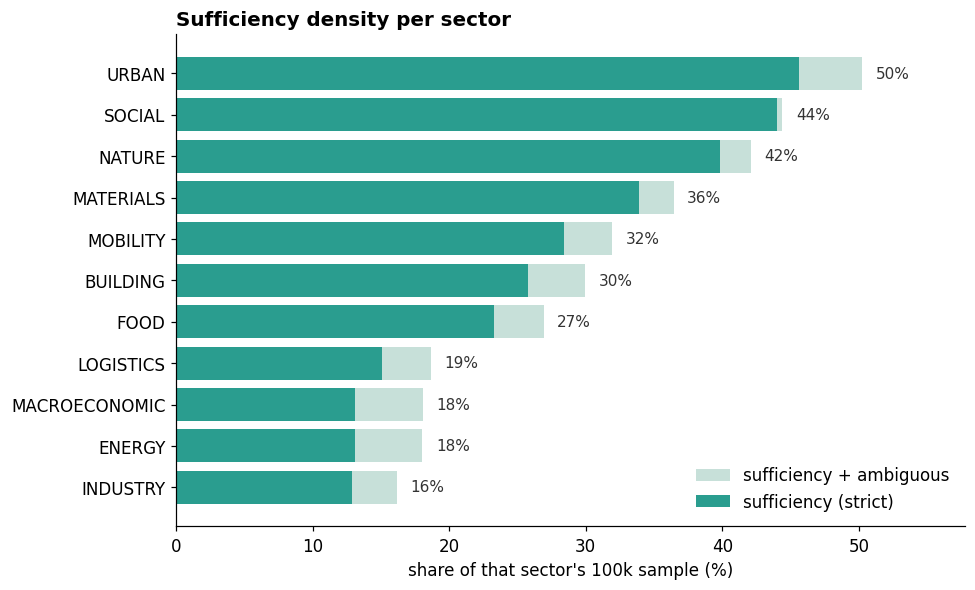

In [11]:
sec_density = (
    df.assign(is_suff=(df["category"] == "sufficiency").astype(int),
              is_suff_related=df["category"].isin(["sufficiency", "ambiguous"]).astype(int))
    .groupby("sector")[["is_suff", "is_suff_related"]]
    .mean()
    .sort_values("is_suff_related")
)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(sec_density.index, sec_density["is_suff_related"] * 100, color="#c7e0d9", label="sufficiency + ambiguous")
ax.barh(sec_density.index, sec_density["is_suff"] * 100, color="#2a9d8f", label="sufficiency (strict)")
for i, (sec, row) in enumerate(sec_density.iterrows()):
    ax.text(row["is_suff_related"] * 100 + 1, i, f"{row['is_suff_related']*100:.0f}%", va="center", fontsize=10, color="#333")
ax.set_xlim(0, sec_density["is_suff_related"].max() * 100 * 1.15)
ax.set_xlabel("share of that sector's 100k sample (%)")
ax.set_title("Sufficiency density per sector", fontsize=13, fontweight="bold", loc="left")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

## 10. Cost + throughput — what this run actually took

For context on scaling to 1.5M:

In [12]:
cost_per_class = 0.00019   # observed per-call cost, cached prompt
cost_per_judge = 0.0005     # judge is longer, less caching benefit

n_class = int(len(df))
n_judge = int(len(judgments))

print(f"Classifications: {n_class:,}   cost ≈ ${n_class * cost_per_class:.2f}")
print(f"Cluster verdicts: {n_judge:,}   cost ≈ ${n_judge * cost_per_judge:.2f}")
print()
print(f"Wall clock: classifier ~110 min at 48 concurrency; judge ~15 min at 4 concurrency")
print()
print("Extrapolation to full 1.47M dataset (single classification pass):")
print(f"  classifier: 1,465,440 × ${cost_per_class:.5f} = ${1_465_440 * cost_per_class:.0f}")
print(f"  judge full ~2,000 clusters:                 = ${2000 * cost_per_judge:.2f}")
print(f"  total ≈ ${1_465_440 * cost_per_class + 2000 * cost_per_judge:.0f}")

Classifications: 99,999   cost ≈ $19.00
Cluster verdicts: 433   cost ≈ $0.22

Wall clock: classifier ~110 min at 48 concurrency; judge ~15 min at 4 concurrency

Extrapolation to full 1.47M dataset (single classification pass):
  classifier: 1,465,440 × $0.00019 = $278
  judge full ~2,000 clusters:                 = $1.00
  total ≈ $279
